In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
import operator

In [2]:
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: Union[str, ForwardRef('os.PathLike[str]'), NoneType] = None, stream: Optional[IO[str]] = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: Optional[str] = 'utf-8') -> bool>

In [3]:
model = ChatOpenAI(model='gpt-4o-mini')

In [4]:
class EvaluationSchema(BaseModel):
    
    feedback: str = Field(description='Detailed feedback for the essay')
    score: int = Field(description='Score out of 10',ge=0,le=10)
    

In [5]:
structured_model = model.with_structured_output(EvaluationSchema)

In [6]:
essay = """
Technology in Modern Life

Technology today is everywhere, from the alarm on our phone in the morning to the last scroll before we sleep at night. It has become something we cannot imagine living without. Many people say it made us lazy, but in reality it also made life more easy and connected.

One of the biggest changes is in communication. Before, people wrote letters and waited weeks for reply. Now, with one click we can video call anyone in the world. Education also changed a lot. Online platforms and YouTube makes learning possible for students even in remote areas. During Covid pandemic, technology was the only bridge between teachers and students.

In health, machines like MRI, ventilators and even simple smart watches saves lives daily. Apps help in booking doctors, ordering medicine and spreading awareness. Daily life is also full of technology, with apps for shopping, travel and food delivery making things faster.

Still, it has disadvantages. Too much screen time cause health problems and social media often brings fake news, addiction and privacy loss.

In conclusion, technology is like a double edge sword. If we use it wisely, it is blessing. If misused, it can become a curse for society.
"""

In [7]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
structured_model.invoke(prompt).score

6

In [8]:
class CSSState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_score: Annotated[list[int],operator.add]
    avg_score: float

In [9]:
def evaluate_language(state: CSSState):
    
    prompt =  f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)
    return {'language_feedback': output.feedback,'individual_score':[output.score]}

In [10]:
def evaluate_analysis(state: CSSState):
    
    prompt =  f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)
    return {'analysis_feedback': output.feedback,'individual_score':[output.score]}

In [11]:
def evaluate_thought(state: CSSState):
    
    prompt =  f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)
    return {'clarity_feedback': output.feedback,'individual_score':[output.score]}

In [12]:
def final_evaluation(state: CSSState):
    #summary feedback
    prompt = f"Based on the following feedbacks create a summarized feedback \n language feedback - {state['language_feedback']}  \n depth of analysis - {state['analysis_feedback']} \n calarity of thought - {state['clarity_feedback']} "
    overall_feedback = model.invoke(prompt).content
    #avg
    
    avg_score = sum(state['individual_score'])/len(state['individual_score'])
    
    return {'overall_feedback': overall_feedback,'avg_score':avg_score}

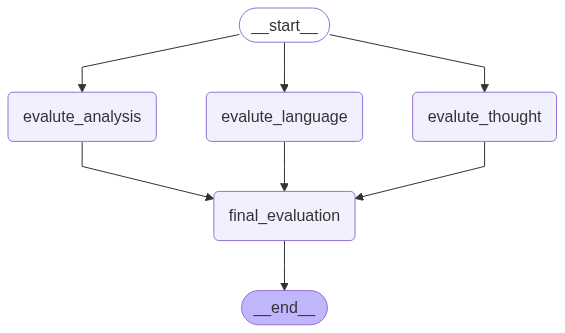

In [ ]:
graph = StateGraph(CSSState)

graph.add_node('evalute_language',evaluate_language)
graph.add_node('evalute_analysis',evaluate_analysis)
graph.add_node('evalute_thought',evaluate_thought)
graph.add_node('final_evaluation',final_evaluation)

graph.add_edge(START,'evalute_language')
graph.add_edge(START,'evalute_analysis')
graph.add_edge(START,'evalute_thought')
graph.add_edge('evalute_language','final_evaluation')
graph.add_edge('evalute_analysis','final_evaluation')
graph.add_edge('evalute_thought','final_evaluation')
graph.add_edge('final_evaluation',END)

workflow = graph.compile()
workflow


In [14]:
initial_state = {
    'essay': essay
}
workflow.invoke(initial_state)

{'essay': '\nTechnology in Modern Life\n\nTechnology today is everywhere, from the alarm on our phone in the morning to the last scroll before we sleep at night. It has become something we cannot imagine living without. Many people say it made us lazy, but in reality it also made life more easy and connected.\n\nOne of the biggest changes is in communication. Before, people wrote letters and waited weeks for reply. Now, with one click we can video call anyone in the world. Education also changed a lot. Online platforms and YouTube makes learning possible for students even in remote areas. During Covid pandemic, technology was the only bridge between teachers and students.\n\nIn health, machines like MRI, ventilators and even simple smart watches saves lives daily. Apps help in booking doctors, ordering medicine and spreading awareness. Daily life is also full of technology, with apps for shopping, travel and food delivery making things faster.\n\nStill, it has disadvantages. Too much s